# 01 – Data analysis ter fetchanje podatkov za Slovenijo

Analiza zgodovinskih podatkov o cenah električne energije za Slovenijo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
from obsyd import Obsyd

In [4]:
client = Obsyd()

In [5]:
df = client.series(
    "price.dayahead",
    "DE_LU",
    start="2026-01-01",
    end="2026-01-07"
)

In [6]:
df.head()

,value
datetime_utc,
2026-01-01 00:00:00+00:00,38.49
2026-01-01 01:00:00+00:00,19.78
2026-01-01 02:00:00+00:00,8.20
2026-01-01 03:00:00+00:00,4.45
2026-01-01 04:00:00+00:00,2.24


In [7]:
df_si = client.series(
    "price.dayahead",
    "SI",
    start="2026-01-01",
    end="2026-01-07"
)

df_si.head()

,value
datetime_utc,
2026-01-01 00:00:00+00:00,90.32
2026-01-01 01:00:00+00:00,85.74
2026-01-01 02:00:00+00:00,70.16
2026-01-01 03:00:00+00:00,58.78
2026-01-01 04:00:00+00:00,62.92


In [8]:
df_si.shape

(144, 1)

In [9]:
df_si.describe()

,value
count,144.000000
mean,100.961250
std,34.866201
min,27.280000
25%,84.102500
50%,94.195000
75%,115.085000
max,224.910000


In [10]:
df_si.index.min(), df_si.index.max()

(Timestamp('2026-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2026-01-06 23:00:00+0000', tz='UTC'))

In [11]:
df_si.tail()

,value
datetime_utc,
2026-01-06 19:00:00+00:00,122.04
2026-01-06 20:00:00+00:00,114.35
2026-01-06 21:00:00+00:00,108.72
2026-01-06 22:00:00+00:00,94.93
2026-01-06 23:00:00+00:00,94.57


In [12]:
df = client.series(
    "price.dayahead",
    "SI",
    start="2026-01-01",
    end="2026-01-07",
)

In [13]:
df_si = client.series(
    "price.dayahead",
    "SI",
    start="2026-01-01",
    end="2026-01-07"
)

df_si.head()

,value
datetime_utc,
2026-01-01 00:00:00+00:00,90.32
2026-01-01 01:00:00+00:00,85.74
2026-01-01 02:00:00+00:00,70.16
2026-01-01 03:00:00+00:00,58.78
2026-01-01 04:00:00+00:00,62.92


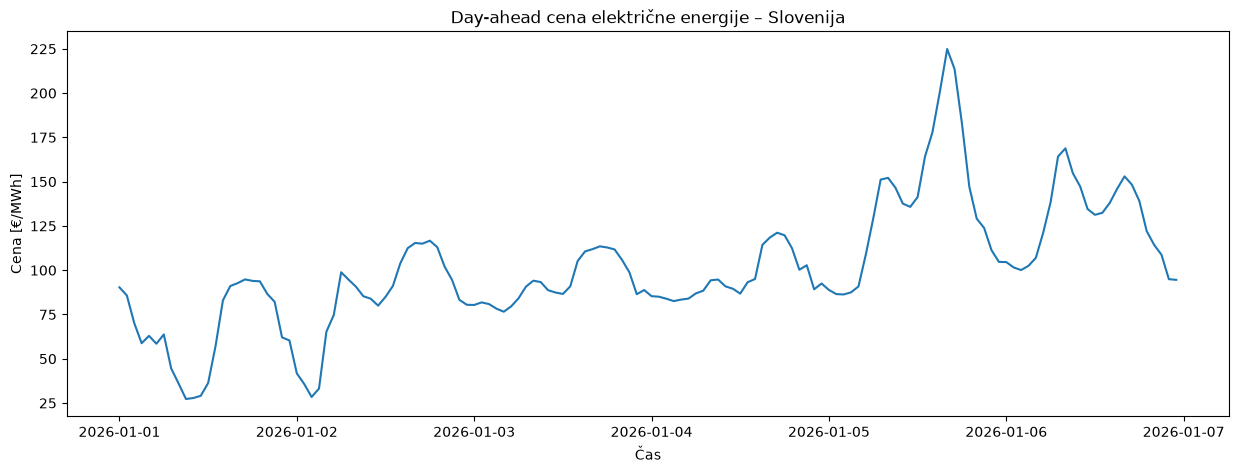

In [14]:
plt.figure(figsize=(15, 5))

plt.plot(df_si.index, df_si["value"])

plt.xlabel("Čas")
plt.ylabel("Cena [€/MWh]")
plt.title("Day-ahead cena električne energije – Slovenija")

plt.show()

In [15]:
df_si = df_si.copy()

df_si["hour"] = df_si.index.hour
df_si["day_of_week"] = df_si.index.dayofweek
df_si["month"] = df_si.index.month
df_si["is_weekend"] = df_si.index.dayofweek >= 5

In [16]:
df_si.head()

,value,hour,day_of_week,month,is_weekend
datetime_utc,,,,,
2026-01-01 00:00:00+00:00,90.32,0,3,1,False
2026-01-01 01:00:00+00:00,85.74,1,3,1,False
2026-01-01 02:00:00+00:00,70.16,2,3,1,False
2026-01-01 03:00:00+00:00,58.78,3,3,1,False
2026-01-01 04:00:00+00:00,62.92,4,3,1,False


In [17]:
hourly_prices = df_si.groupby("hour")["value"].mean()

hourly_prices

hour
0      81.871667
1      79.401667
2      74.963333
3      73.795000
4      81.003333
5      87.845000
6     100.238333
7     105.620000
8     106.018333
9     100.346667
10     96.035000
11     92.720000
12     94.531667
13    104.813333
14    117.140000
15    129.148333
16    136.048333
17    134.385000
18    127.520000
19    116.666667
20    106.366667
21    101.820000
22     87.871667
23     86.900000
Name: value, dtype: float64

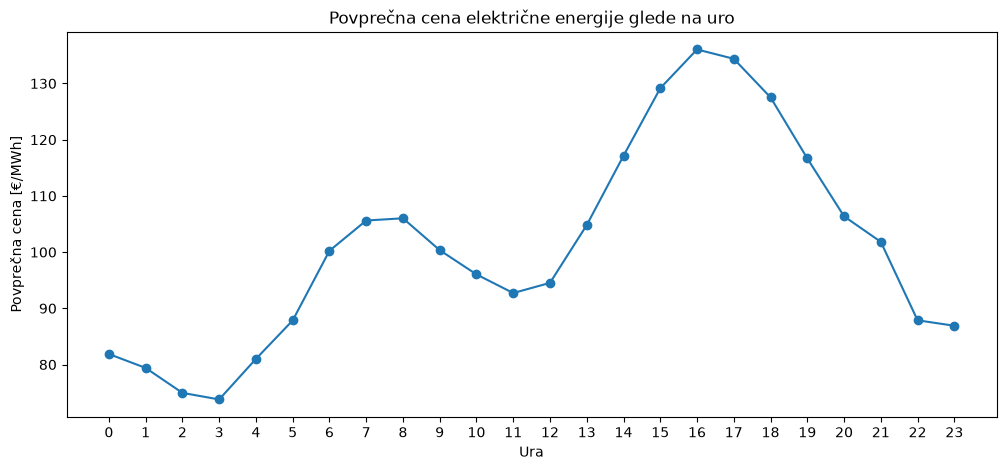

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(hourly_prices.index, hourly_prices.values, marker="o")

plt.xlabel("Ura")
plt.ylabel("Povprečna cena [€/MWh]")
plt.title("Povprečna cena električne energije glede na uro")

plt.xticks(range(24))
plt.show()

In [19]:
weekday_prices = df_si.groupby("day_of_week")["value"].mean()

weekday_prices

day_of_week
0    138.444167
1    127.824583
3     66.199167
4     84.385833
5     93.292083
6     95.621667
Name: value, dtype: float64

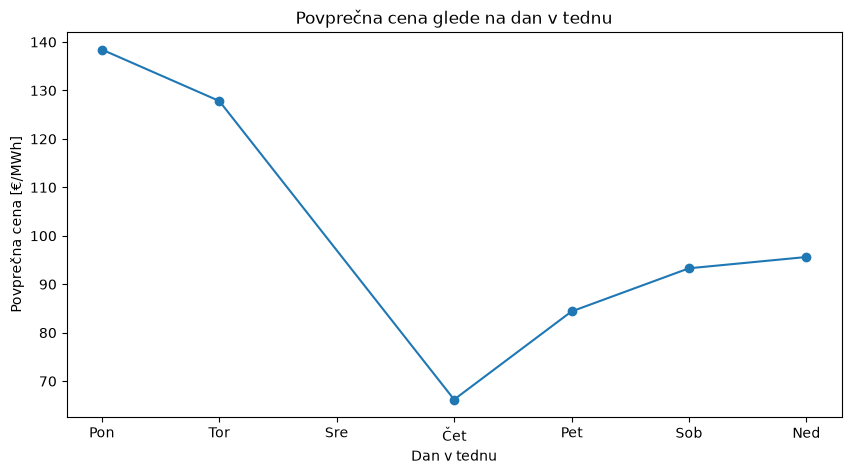

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(weekday_prices.index, weekday_prices.values, marker="o")

plt.xlabel("Dan v tednu")
plt.ylabel("Povprečna cena [€/MWh]")
plt.title("Povprečna cena glede na dan v tednu")

plt.xticks(
    range(7),
    ["Pon", "Tor", "Sre", "Čet", "Pet", "Sob", "Ned"]
)

plt.show()

In [21]:
weekend_prices = df_si.groupby("is_weekend")["value"].mean()

weekend_prices

is_weekend
False    104.213437
True      94.456875
Name: value, dtype: float64

In [22]:
df_si.nsmallest(10, "value")[["value", "hour", "day_of_week"]]

,value,hour,day_of_week
datetime_utc,,,
2026-01-01 09:00:00+00:00,27.28,9,3
2026-01-01 10:00:00+00:00,27.83,10,3
2026-01-02 02:00:00+00:00,28.43,2,4
2026-01-01 11:00:00+00:00,29.07,11,3
2026-01-02 03:00:00+00:00,33.16,3,4
2026-01-02 01:00:00+00:00,35.74,1,4
2026-01-01 08:00:00+00:00,36.05,8,3
2026-01-01 12:00:00+00:00,36.30,12,3
2026-01-02 00:00:00+00:00,41.75,0,4


In [23]:
df_si.nlargest(10, "value")[["value", "hour", "day_of_week"]]

,value,hour,day_of_week
datetime_utc,,,
2026-01-05 16:00:00+00:00,224.91,16,0
2026-01-05 17:00:00+00:00,213.59,17,0
2026-01-05 15:00:00+00:00,200.50,15,0
2026-01-05 18:00:00+00:00,182.80,18,0
2026-01-05 14:00:00+00:00,177.79,14,0
2026-01-06 08:00:00+00:00,168.82,8,1
2026-01-06 07:00:00+00:00,164.19,7,1
2026-01-05 13:00:00+00:00,164.17,13,0
2026-01-06 09:00:00+00:00,154.84,9,1


In [24]:
price_heatmap = df_si.pivot_table(
    values="value",
    index="hour",
    columns="day_of_week",
    aggfunc="mean"
)

price_heatmap

day_of_week,0,1,3,4,5,6
hour,,,,,,
0,88.85,104.60,90.32,41.75,80.38,85.33
1,86.51,101.55,85.74,35.74,81.83,85.04
2,86.31,100.09,70.16,28.43,80.89,83.90
3,87.50,102.45,58.78,33.16,78.32,82.56
4,90.86,107.00,62.92,65.26,76.57,83.41
5,109.02,121.29,58.48,74.73,79.56,83.99
6,129.31,138.50,63.73,98.84,84.14,86.91
7,151.18,164.19,44.52,94.68,90.69,88.46
8,152.15,168.82,36.05,90.70,94.09,94.30


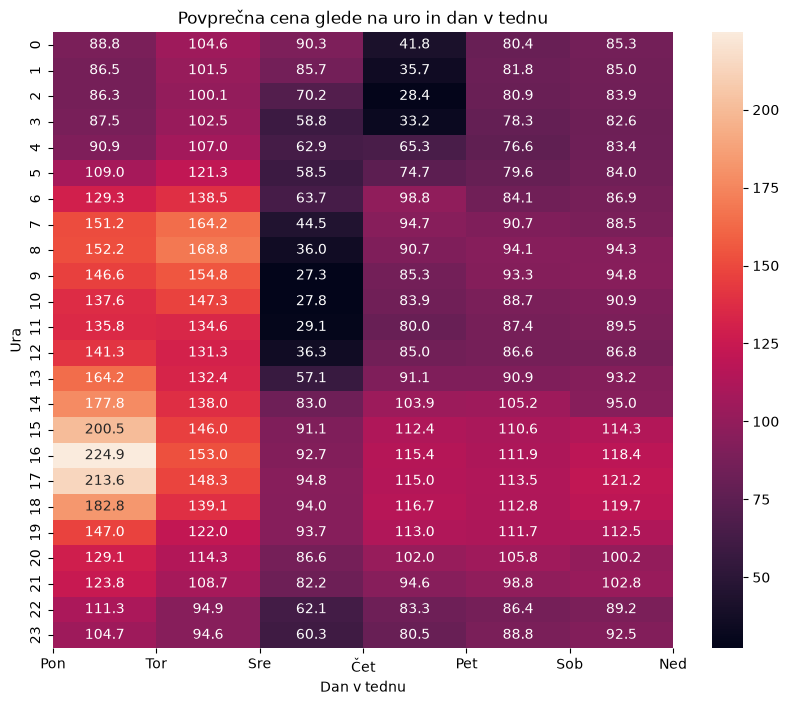

In [25]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    price_heatmap,
    annot=True,
    fmt=".1f"
)

plt.xlabel("Dan v tednu")
plt.ylabel("Ura")
plt.title("Povprečna cena glede na uro in dan v tednu")

plt.xticks(
    range(7),
    ["Pon", "Tor", "Sre", "Čet", "Pet", "Sob", "Ned"]
)

plt.show()

In [26]:
def cheapest_hours(df, start_hour, end_hour, n=5):
    available = df[
        (df["hour"] >= start_hour) &
        (df["hour"] <= end_hour)
    ]

    return available.nsmallest(n, "value")

In [27]:
cheapest_hours(df_si, 18, 23)

,value,hour,day_of_week,month,is_weekend
datetime_utc,,,,,
2026-01-01 23:00:00+00:00,60.34,23,3,1,False
2026-01-01 22:00:00+00:00,62.08,22,3,1,False
2026-01-02 23:00:00+00:00,80.48,23,4,1,False
2026-01-01 21:00:00+00:00,82.17,21,3,1,False
2026-01-02 22:00:00+00:00,83.27,22,4,1,False


Diagnosticiranje zakaj so manjkajoči podatki pri fetchanju

In [28]:
df_si = pd.read_csv(
    "../data/raw/electricity/prices/slovenia_day_ahead_prices.csv",
    index_col="datetime_utc",
    parse_dates=True
)

df_si.head()

,value
datetime_utc,
2024-01-01 00:00:00+00:00,0.01
2024-01-01 01:00:00+00:00,0.03
2024-01-01 02:00:00+00:00,0.00
2024-01-01 05:00:00+00:00,0.02
2024-01-01 06:00:00+00:00,0.00


In [29]:
df_si.shape

(22889, 1)

In [30]:
df_si.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 22889 entries, 2024-01-01 00:00:00+00:00 to 2026-08-14 23:00:00+00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   22889 non-null  float64
dtypes: float64(1)
memory usage: 357.6 KB


In [31]:
df_si["value"].describe()

count    22889.000000
mean       102.216591
std         59.649843
min       -473.750000
25%         74.600000
50%        101.520000
75%        128.870000
max       1041.470000
Name: value, dtype: float64

In [32]:
df_si["value"].min(), df_si["value"].max()

(np.float64(-473.75), np.float64(1041.47))

In [33]:
expected_index = pd.date_range(
    start=df_si.index.min(),
    end=df_si.index.max(),
    freq="h",
    tz="UTC"
)

missing_timestamps = expected_index.difference(df_si.index)

len(missing_timestamps)

79

In [34]:
missing_timestamps[:20]

DatetimeIndex(['2024-01-01 03:00:00+00:00', '2024-01-01 04:00:00+00:00',
               '2024-01-01 07:00:00+00:00', '2024-01-06 03:00:00+00:00',
               '2024-03-09 07:00:00+00:00', '2024-03-24 08:00:00+00:00',
               '2024-03-24 09:00:00+00:00', '2024-03-24 10:00:00+00:00',
               '2024-03-24 11:00:00+00:00', '2024-03-24 12:00:00+00:00',
               '2024-03-24 13:00:00+00:00', '2024-04-01 13:00:00+00:00',
               '2024-04-01 14:00:00+00:00', '2024-04-07 01:00:00+00:00',
               '2024-04-07 02:00:00+00:00', '2024-04-07 03:00:00+00:00',
               '2024-04-07 04:00:00+00:00', '2024-04-07 05:00:00+00:00',
               '2024-04-07 06:00:00+00:00', '2024-04-27 01:00:00+00:00'],
              dtype='datetime64[us, UTC]', freq=None)

In [35]:
df_si.groupby(df_si.index.year).size()

datetime_utc
2024    8747
2025    8724
2026    5418
dtype: int64

In [36]:
df_si.groupby(df_si.index.to_period("M")).size()

/tmp/ipykernel_34561/2112144652.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_si.groupby(df_si.index.to_period("M")).size()


datetime_utc
2024-01    740
2024-02    696
2024-03    737
2024-04    709
2024-05    740
2024-06    717
2024-07    742
2024-08    743
2024-09    718
2024-10    743
2024-11    719
2024-12    743
2025-01    741
2025-02    670
2025-03    744
2025-04    717
2025-05    742
2025-06    719
2025-07    736
2025-08    735
2025-09    713
2025-10    743
2025-11    720
2025-12    744
2026-01    744
2026-02    671
2026-03    744
2026-04    720
2026-05    740
2026-06    720
2026-07    743
2026-08    336
Freq: M, dtype: int64

Testiranje processed podatkov

In [37]:
df_processed = pd.read_csv(
    "../data/processed/electricity/prices/slovenia_day_ahead_prices_processed.csv",
    parse_dates=["datetime_utc"]
)

df_processed.head()

,datetime_utc,price,hour,day_of_week,day,month,year,is_weekend
0,2024-01-01 00:00:00+00:00,0.01,0,0,1,1,2024,False
1,2024-01-01 01:00:00+00:00,0.03,1,0,1,1,2024,False
2,2024-01-01 02:00:00+00:00,0.00,2,0,1,1,2024,False
3,2024-01-01 05:00:00+00:00,0.02,5,0,1,1,2024,False
4,2024-01-01 06:00:00+00:00,0.00,6,0,1,1,2024,False


In [38]:
df_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 22889 entries, 0 to 22888
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   datetime_utc  22889 non-null  datetime64[us, UTC]
 1   price         22889 non-null  float64            
 2   hour          22889 non-null  int64              
 3   day_of_week   22889 non-null  int64              
 4   day           22889 non-null  int64              
 5   month         22889 non-null  int64              
 6   year          22889 non-null  int64              
 7   is_weekend    22889 non-null  bool               
dtypes: bool(1), datetime64[us, UTC](1), float64(1), int64(5)
memory usage: 1.2 MB


In [39]:
df_processed.isna().sum()

datetime_utc    0
price           0
hour            0
day_of_week     0
day             0
month           0
year            0
is_weekend      0
dtype: int64

In [40]:
df_ml = df_processed.copy()

df_ml = df_ml.set_index("datetime_utc")
df_ml = df_ml.sort_index()

In [41]:
df_ml.head()

,price,hour,day_of_week,day,month,year,is_weekend
datetime_utc,,,,,,,
2024-01-01 00:00:00+00:00,0.01,0,0,1,1,2024,False
2024-01-01 01:00:00+00:00,0.03,1,0,1,1,2024,False
2024-01-01 02:00:00+00:00,0.00,2,0,1,1,2024,False
2024-01-01 05:00:00+00:00,0.02,5,0,1,1,2024,False
2024-01-01 06:00:00+00:00,0.00,6,0,1,1,2024,False


In [42]:
df_ml["price_lag_1"] = df_ml["price"].shift(1)
df_ml["price_lag_2"] = df_ml["price"].shift(2)
df_ml["price_lag_3"] = df_ml["price"].shift(3)
df_ml["price_lag_24"] = df_ml["price"].shift(24)
df_ml["price_lag_48"] = df_ml["price"].shift(48)
df_ml["price_lag_168"] = df_ml["price"].shift(168)

In [43]:
df_ml.head(10)

,price,hour,day_of_week,day,month,year,is_weekend,price_lag_1,price_lag_2,price_lag_3,price_lag_24,price_lag_48,price_lag_168
datetime_utc,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,0.01,0,0,1,1,2024,False,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00+00:00,0.03,1,0,1,1,2024,False,0.01,NaN,NaN,NaN,NaN,NaN
2024-01-01 02:00:00+00:00,0.00,2,0,1,1,2024,False,0.03,0.01,NaN,NaN,NaN,NaN
2024-01-01 05:00:00+00:00,0.02,5,0,1,1,2024,False,0.00,0.03,0.01,NaN,NaN,NaN
2024-01-01 06:00:00+00:00,0.00,6,0,1,1,2024,False,0.02,0.00,0.03,NaN,NaN,NaN
2024-01-01 08:00:00+00:00,0.04,8,0,1,1,2024,False,0.00,0.02,0.00,NaN,NaN,NaN
2024-01-01 09:00:00+00:00,0.06,9,0,1,1,2024,False,0.04,0.00,0.02,NaN,NaN,NaN
2024-01-01 10:00:00+00:00,0.54,10,0,1,1,2024,False,0.06,0.04,0.00,NaN,NaN,NaN
2024-01-01 11:00:00+00:00,2.24,11,0,1,1,2024,False,0.54,0.06,0.04,NaN,NaN,NaN


Katere vse cone obstajajo?

In [44]:
from obsyd import Obsyd

client = Obsyd()

zones = client.zones()

zones

{'default': 'DE_LU',
 'enabled_keys': ['DE_LU',
  'FR',
  'NL',
  'BE',
  'AT',
  'ES',
  'PT',
  'PL',
  'CZ',
  'HU',
  'RO',
  'GR',
  'IE_SEM',
  'IT_NORD',
  'IT_CENTRO_NORD',
  'IT_CENTRO_SUD',
  'IT_SUD',
  'IT_SICILIA',
  'IT_SARDEGNA',
  'IT_CALABRIA',
  'BG',
  'HR',
  'SI',
  'SK',
  'FI',
  'DK1',
  'DK2',
  'CH',
  'NO1',
  'NO2',
  'NO3',
  'NO4',
  'NO5',
  'SE1',
  'SE2',
  'SE3',
  'SE4'],
 'zones': [{'key': 'DE_LU',
   'label': 'DE-LU',
   'ec_country': 'de',
   'has_flows': True,
   'enabled': True},
  {'key': 'FR',
   'label': 'FR',
   'ec_country': 'fr',
   'has_flows': True,
   'enabled': True},
  {'key': 'NL',
   'label': 'NL',
   'ec_country': 'nl',
   'has_flows': True,
   'enabled': True},
  {'key': 'BE',
   'label': 'BE',
   'ec_country': 'be',
   'has_flows': True,
   'enabled': True},
  {'key': 'AT',
   'label': 'AT',
   'ec_country': 'at',
   'has_flows': True,
   'enabled': True},
  {'key': 'ES',
   'label': 'ES',
   'ec_country': 'es',
   'has_flows': Tr